# HST data tests

In [21]:
import planetmapper
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math
from astropy.io import fits
import time
from scipy.signal import correlate
import scipy as sp
import datetime
import csv
import os
import glob
import pandas as pd
from scipy.signal import find_peaks, welch

# main class where these functions are dumped:
from zonalwindfunctions import ZWP_Class

print(matplotlib.get_backend())


module://matplotlib_inline.backend_inline


In [2]:
long_res, lat_res = 360, 180
long_array, lat_array = np.linspace(360, 0,long_res), np.linspace(-90, 90,lat_res)
long_array_hi, lat_array_hi = np.linspace(360, 0,long_res*2), np.linspace(-90, 90,lat_res*2)
R_J = 71492e3 # m
R_J_p = 66854e3 # m


'''
Load some HST data for comparison and get the appropriate ∆t for the case currently being used.
'''

hst_wind_1D = np.genfromtxt('OPAL/Simon+2015_ZWP_HST.csv', delimiter=",", dtype=None, encoding=None, names=True)[:]

opal_2015        = pd.read_excel('OPAL/Simon+2015_ZWP_HST.xlsx') # with only LAT and FMZW
opal_2016        = pd.read_excel('OPAL/ZWP_j2016.xlsx')
opal_2017        = pd.read_excel('OPAL/2017_631.xlsx')
opal_2018        = pd.read_excel('OPAL/2018_631.xlsx')
opal_2019        = pd.read_excel('OPAL/2019_631.xlsx')
opal_2020        = pd.read_excel('OPAL/2020_631.xlsx')
opal_2021        = pd.read_excel('OPAL/2021_631.xlsx')
opal_2022        = pd.read_excel('OPAL/2022_631.xlsx')
opal_2024b       = pd.read_excel('OPAL/2024b_631.xlsx')
opal_nov_2024_df = pd.read_excel('OPAL/2024nov_jup_502.xlsx')

HST_ZWP_list = [opal_2016 ,opal_2017 ,opal_2018 ,opal_2019 ,opal_2020 ,opal_2021 ,opal_2022 ,opal_2024b,opal_nov_2024_df]

# convert HST planetographic latitudes to planetocentric
centric_lat_HST = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, opal_nov_2024_df['LAT']))
centric_lat_HST_2015 = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, hst_wind_1D['y']))[:]

-72.0 72.0 2881
-79.8 79.7 1596
-79.8 79.7 1596
-79.9 79.9 1598
-79.8 79.7 1596
-90.0 89.9 1800
-90.0 89.9 1800
-90.0 89.9 1800
-90.0 89.9 1800


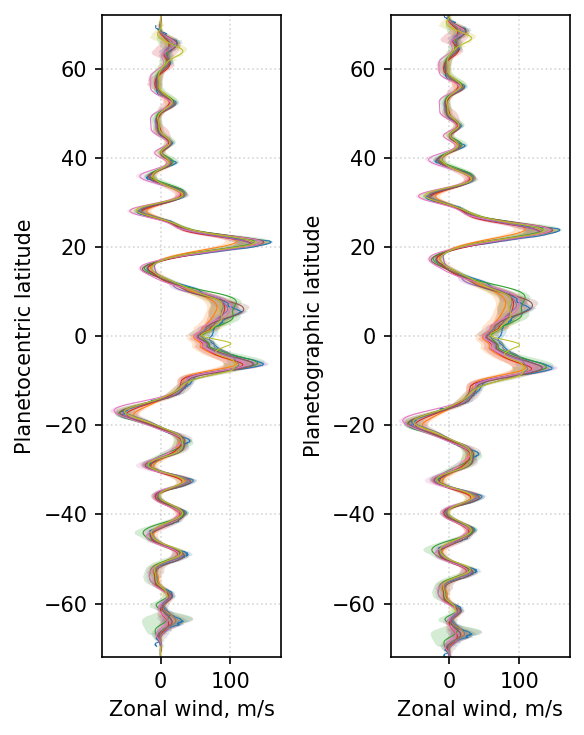

9


In [113]:

%matplotlib inline

plt.figure(figsize=(4,5), dpi=150)
plt.subplot(121)
for zwp in HST_ZWP_list:
    plt.fill_betweenx(np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, zwp['LAT'])), zwp['FMZW'] - zwp['ERROR'], zwp['FMZW'] + zwp['ERROR'], alpha=0.2) 
    plt.plot(zwp['FMZW'], np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, zwp['LAT'])), lw=0.5)
    print(np.min(zwp['LAT']), np.max(zwp['LAT']), len(zwp['LAT']))

plt.xlabel('Zonal wind, m/s'), plt.ylabel('Planetocentric latitude')
plt.grid(True, ls=':', alpha=0.5)
plt.ylim(-72, 72)
# plt.show()

plt.subplot(122)
for zwp in HST_ZWP_list:
    plt.fill_betweenx(zwp['LAT'], zwp['FMZW'] - zwp['ERROR'], zwp['FMZW'] + zwp['ERROR'], alpha=0.2) 
    plt.plot(zwp['FMZW'], zwp['LAT'], lw=0.5)

plt.xlabel('Zonal wind, m/s'), plt.ylabel('Planetographic latitude')
plt.grid(True, ls=':', alpha=0.5)
plt.ylim(-72, 72)
plt.tight_layout()
plt.show()

print(len(HST_ZWP_list))

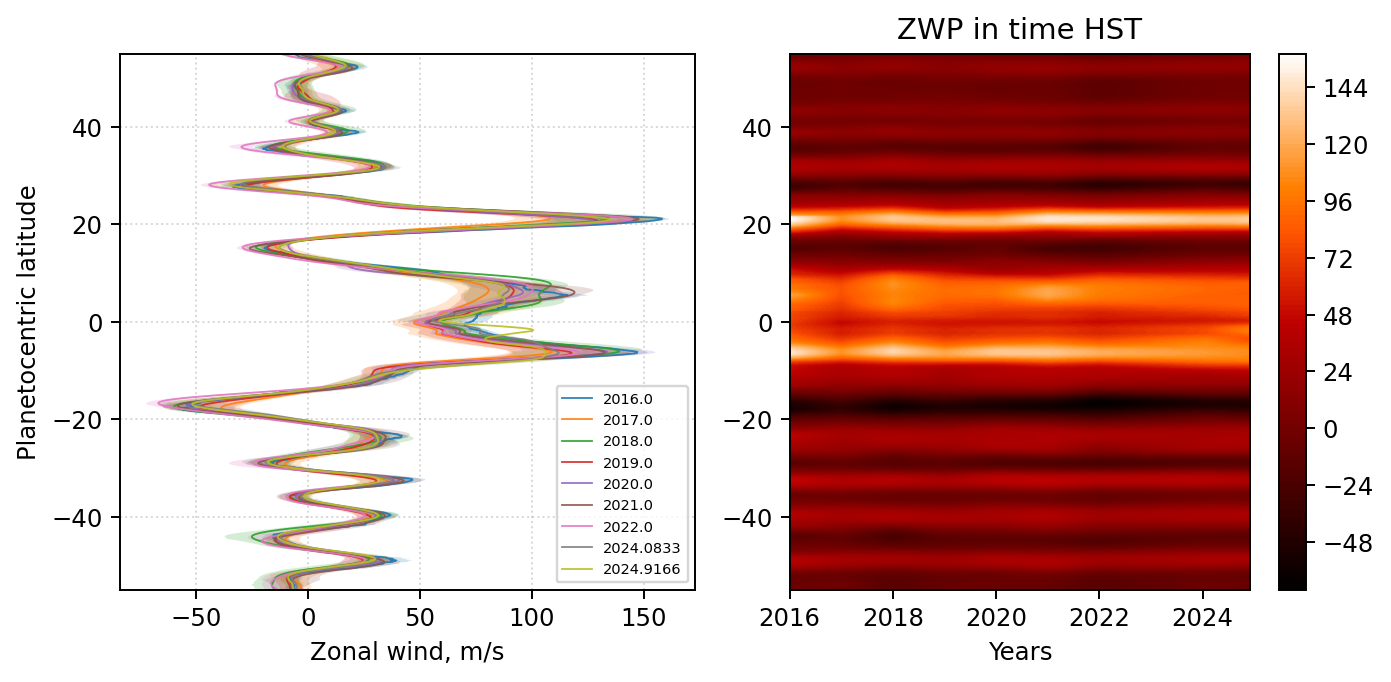

In [ ]:
'''
Homogenize the arrays to the lowest resolution HST latitutde array...
'''

HST_interp_lat_array = np.linspace(-72, 72, 1596) # planetographic still as it is based on the HST data. Interp will use this.
HST_interp_lat_array_cent = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, HST_interp_lat_array)) # in planetocentric

HST_homo_dataframe = np.empty((len(HST_ZWP_list), len(HST_interp_lat_array)))
year_arr = np.array([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2024.0833, 2024.9166])

%matplotlib inline
plt.figure(figsize=(8,4), dpi=175)
plt.subplot(121)
for iz, zwp in enumerate(HST_ZWP_list):
    HST_homo_dataframe[iz, :] = np.interp(HST_interp_lat_array, zwp['LAT'], zwp['FMZW'], left=None, right=None, period=None)
    plt.fill_betweenx(np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, zwp['LAT'])), zwp['FMZW'] - zwp['ERROR'], zwp['FMZW'] + zwp['ERROR'], alpha=0.2) 
    plt.plot(HST_homo_dataframe[iz, :], HST_interp_lat_array_cent, lw=0.75, alpha=0.9, label=year_arr[iz])

ylim = 55
plt.xlabel('Zonal wind, m/s'), plt.ylabel('Planetocentric latitude')
plt.grid(True, ls=':', alpha=0.5)
plt.ylim(-ylim, ylim)
plt.legend(fontsize='6')

plt.subplot(122)
plt.contourf(year_arr, HST_interp_lat_array_cent, HST_homo_dataframe.T, 128, cmap='gist_heat')
plt.xlabel('Years')
plt.title('ZWP in time HST')
plt.ylim(-ylim, ylim)
plt.tight_layout()
plt.colorbar()
plt.show()

In [ ]:
# np.savez_compressed('OPAL/HST_homo_dataframe', HST_homo_dataframe=[HST_homo_dataframe], 
#                     HST_interp_lat_array=[HST_interp_lat_array],   
#                     HST_interp_lat_array_cent=[HST_interp_lat_array_cent])

In [126]:
time_signal_length__per_lat = len(year_arr)
sampling_interval           = np.mean(np.diff(year_arr)) #* 365.25*24*3600 # Try converting to seconds. This last factor converts the smapling difference from years to seconds
sampling_frequency          = 1/sampling_interval
nyquist                     = sampling_frequency/2

print(time_signal_length__per_lat)
print(sampling_interval          )
print(sampling_frequency         )
print(nyquist                    )

print(HST_homo_dataframe[:, 1000])

FFT_field = np.zeros_like(HST_homo_dataframe)
Fv_field  = np.zeros((len(year_arr)//2 + 1, HST_homo_dataframe.shape[-1]))
Iv_field  = np.zeros((len(year_arr)//2 + 1, HST_homo_dataframe.shape[-1]))

for f in range(HST_homo_dataframe.shape[-1]):
    # Normalized FFT
    FFT_field[:, f] = np.fft.fft(HST_homo_dataframe[:, f]) / time_signal_length__per_lat
    # Frequency vector (one-sided)
    Fv_field[:, f] = np.linspace(0, 1, time_signal_length__per_lat//2 + 1) * nyquist
    Iv_field[:, f] = np.arange(len(Fv_field[:, f]))
    
    # same as above but just doing it for the last latitude for explanatory purposes...
    FTs = np.fft.fft(HST_homo_dataframe[:, 1000]) / time_signal_length__per_lat
    Fv = np.linspace(0, 1, time_signal_length__per_lat//2 + 1) * nyquist
    Iv = np.arange(len(Fv))

9
1.114575000000002
0.8972029697418281
0.44860148487091406
[-11.11442006 -12.43672632 -16.93884057 -11.64610352  -7.63615236
 -14.31423599 -22.48932439  -8.95606251  -8.66057321]


/var/folders/xh/s9lkw5113q98j632zllsplyr0000gq/T/ipykernel_19123/1717919676.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  FFT_field[:, f] = np.fft.fft(HST_homo_dataframe[:, f]) / time_signal_length__per_lat


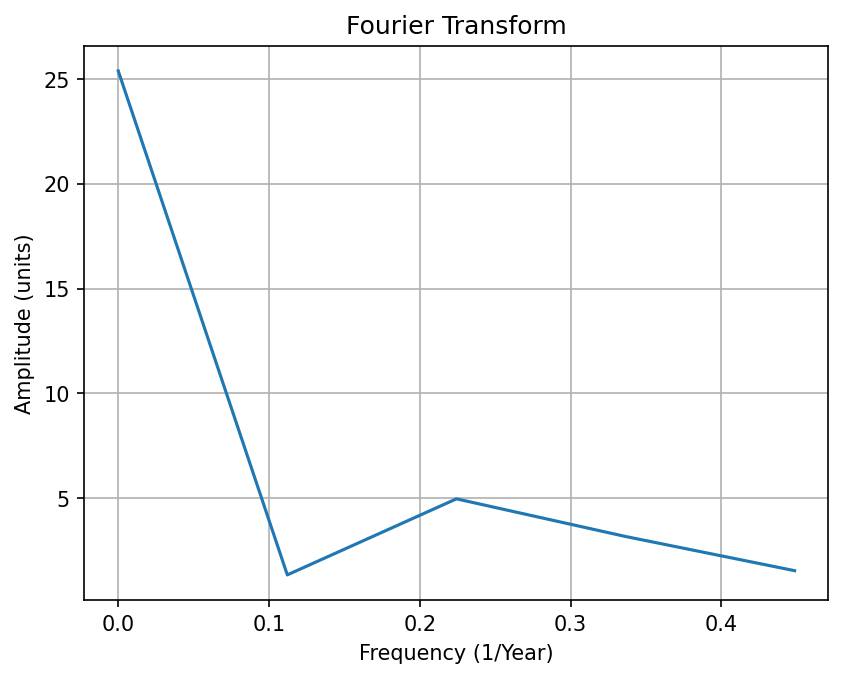

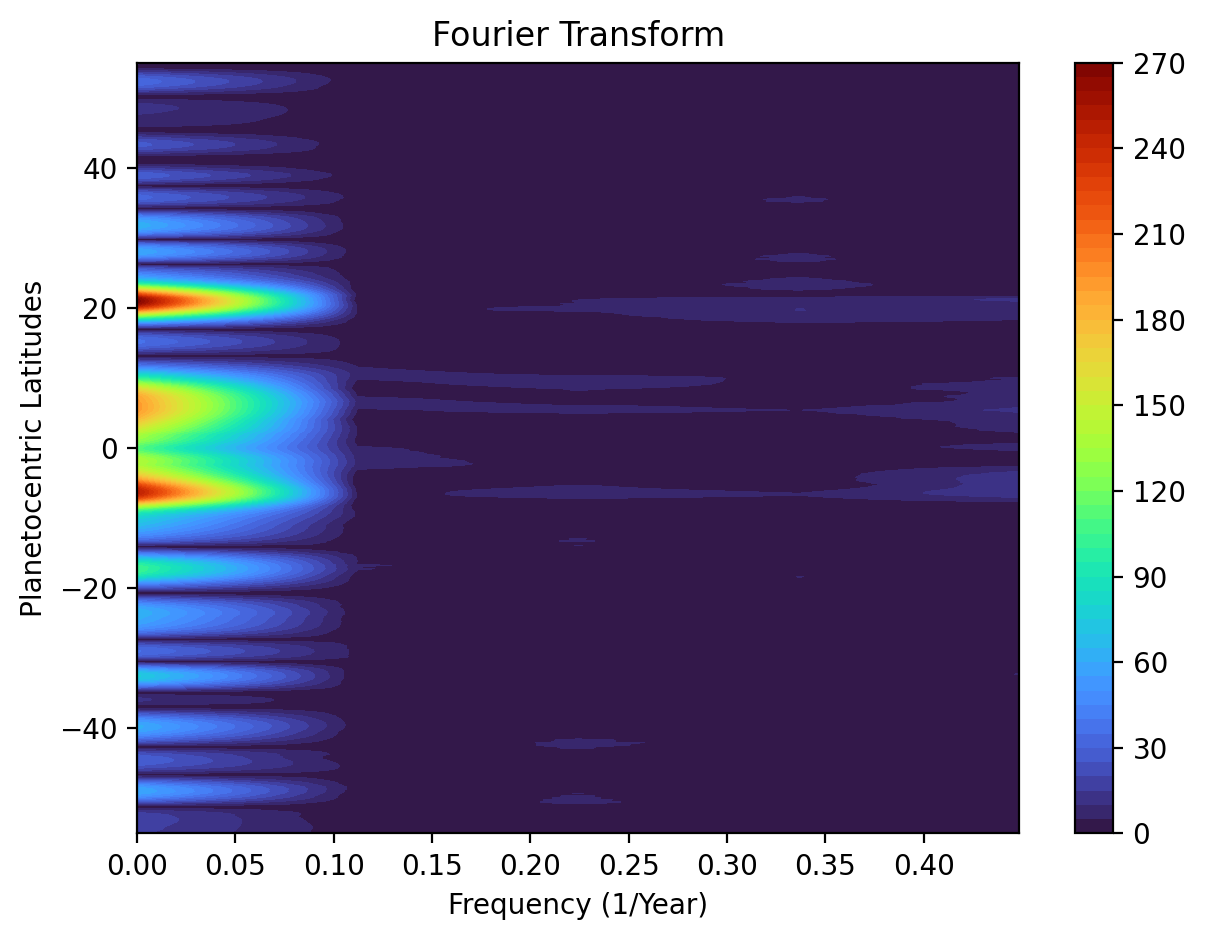

In [130]:

# Find peaks
# pks, locs = find_peaks(np.abs(FTs[Iv]))
# Perd = 1.0 / Fv[locs]   # Periods corresponding to peaks

%matplotlib inline
# Plot Fourier Transform
plt.figure(dpi=150)
plt.plot(Fv, 2 * np.abs(FTs[Iv]))
plt.grid(True)
plt.title('Fourier Transform')
plt.xlabel('Frequency (1/Year)')
# plt.xlabel('Periodicity')
plt.ylabel('Amplitude (units)')


# Plot Fourier Transform
plt.figure(dpi=200)
plt.contourf(Fv_field[:, -1], HST_interp_lat_array_cent, 2 * np.abs(FFT_field[:5, :].T), levels=64, cmap='turbo') 
plt.title('Fourier Transform')
plt.xlabel('Frequency (1/Year)')
plt.colorbar()
plt.ylabel('Planetocentric Latitudes')
plt.ylim(-55, 55)
plt.tight_layout()
plt.show()

In [97]:
# # =====================================================
# # Power Spectral Density (Welch’s method, like MATLAB pwelch)
# # =====================================================
# f_psd, Pxx = welch(HST_homo_dataframe[:, 1000], fs=sampling_frequency, nperseg=time_signal_length__per_lat//1)  # adjust nperseg for smoothing
# plt.figure(dpi=150)
# plt.plot(f_psd, Pxx)
# plt.grid(True)
# plt.title('Power Spectral Density (Welch)')
# plt.xlabel('Frequency [Hz]')
# plt.ylabel('PSD [Power/Hz]')
# plt.show()

In [89]:
Fv_field[:, -1] + 1e-10, 1 / (Fv_field[:, -1] + 1e-10)

(array([1.00000000e-10, 1.12150371e-01, 2.24300743e-01, 3.36451114e-01,
        4.48601485e-01]),
 array([1.00000000e+10, 8.91659999e+00, 4.45830000e+00, 2.97220000e+00,
        2.22915000e+00]))

In [98]:
# for l in range(FFT_field[:5, :].shape[-1]):

#     print(find_peaks(FFT_field[:5, l].T))